In [32]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Trajectron-plus-plus"
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "trajectron"))

print("Paths OK")


Paths OK


In [33]:
import dill
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from environment import Environment
from visualization.visualization import (
    visualize_prediction,
    visualize_distribution
)


In [34]:
PROCESSED_DIR = PROJECT_ROOT / "experiments" / "processed"

with open(PROCESSED_DIR / "eth_test.pkl", "rb") as f:
    eval_env = dill.load(f)

print("Loaded environment")
print("Scenes:", len(eval_env.scenes))


Loaded environment
Scenes: 1


In [35]:
MODEL_DIR = PROJECT_ROOT / "experiments" / "pedestrians" / "models" / \
            "models_26_Dec_2025_14_50_24_eth_demo"

with open(MODEL_DIR / "config.json", "r") as f:
    hyperparams = json.load(f)

hyperparams["incl_robot_node"] = False
hyperparams["offline_scene_graph"] = True

print("Hyperparams loaded")


Hyperparams loaded


In [36]:
from model.model_registrar import ModelRegistrar
from model.online.online_trajectron import OnlineTrajectron

model_registrar = ModelRegistrar(MODEL_DIR, device="cpu")
model_registrar.load_models(iter_num=3)

online_traj = OnlineTrajectron(
    model_registrar,
    hyperparams,
    device="cpu"
)

print("OnlineTrajectron ready")



Loading from /Users/simayyalcin/Trajectron-plus-plus/experiments/pedestrians/models/models_26_Dec_2025_14_50_24_eth_demo/model_registrar-3.pt
Loaded!

OnlineTrajectron ready


/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

In [37]:
scene_idx = 0
scene = eval_env.scenes[scene_idx]

init_timestep = hyperparams["maximum_history_length"]

online_env = Environment(
    node_type_list=eval_env.node_type_list,
    standardization=eval_env.standardization,
    scenes=[scene],
    attention_radius=eval_env.attention_radius,
    robot_type=eval_env.robot_type
)

online_traj.set_environment(online_env, init_timestep)

print("Environment set at timestep", init_timestep)


Environment set at timestep 7


In [38]:
timestep = init_timestep + 1

input_dict = scene.get_clipped_input_dict(
    timestep,
    hyperparams["state"]
)

dists, preds = online_traj.incremental_forward(
    input_dict,
    maps=None,
    prediction_horizon=hyperparams["prediction_horizon"],
    num_samples=20,
    full_dist=True
)

print("Prediction done")


Prediction done


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


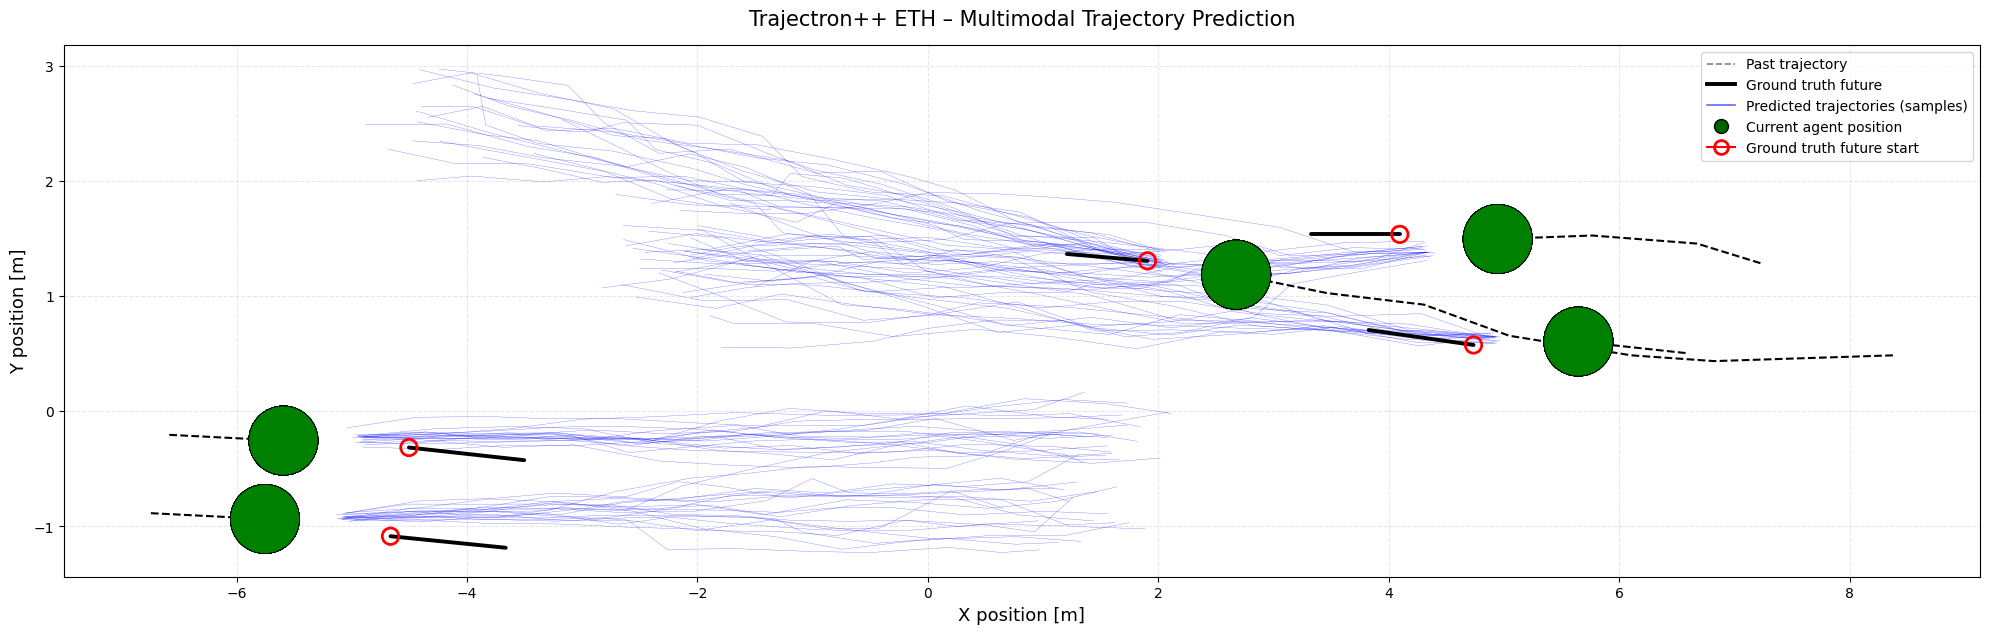

In [39]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(20, 20))

# =========================
# 1️⃣ PREDICTION DISTRIBUTION (GMM ellipses)
# =========================
visualize_distribution(
    ax,
    dists,
    pi_threshold=0.05
)

# =========================
# 2️⃣ PREDICTED TRAJECTORIES + PAST (Trajectron util)
# =========================
visualize_prediction(
    ax,
    {timestep: preds},
    dt=scene.dt,
    max_hl=hyperparams["maximum_history_length"],
    ph=hyperparams["prediction_horizon"]
)

# =========================
# 3️⃣ GROUND TRUTH FUTURE (MANUAL & DISTINCT STYLE)
# =========================
for node in scene.nodes:
    future = node.get(
        np.arange(
            timestep + 1,
            timestep + hyperparams["prediction_horizon"] + 1
        ),
        hyperparams["state"][node.type]
    )

    # Ground truth future → SİYAH, DÜZ, KALIN
    ax.plot(
        future[:, 0],
        future[:, 1],
        color="black",
        linewidth=2.8,
        solid_capstyle="round"
    )

    # Ground truth future start → AÇIK YEŞİL BOŞ DAİRE
    ax.scatter(
        future[0, 0],
        future[0, 1],
        facecolors="none",
        edgecolors="red",
        s=140,
        linewidth=2.0,
        zorder=6
    )


ax.set_xlabel("X position [m]", fontsize=13)
ax.set_ylabel("Y position [m]", fontsize=13)


ax.set_title(
    "Trajectron++ ETH – Multimodal Trajectory Prediction",
    fontsize=15,
    pad=14
)

ax.grid(True, linestyle="--", alpha=0.3)
ax.set_aspect("equal", adjustable="box")


legend_elements = [
    Line2D([0], [0],
           color="gray", linestyle="--", linewidth=1.2,
           label="Past trajectory"),

    Line2D([0], [0],
           color="black", linewidth=2.8,
           label="Ground truth future"),

    Line2D([0], [0],
           color="blue", linewidth=1.2,
           alpha=0.6,
           label="Predicted trajectories (samples)"),

    Line2D([0], [0],
           marker="o", color="w",
           markerfacecolor="darkgreen",
           markeredgecolor="black",
           markersize=10,
           label="Current agent position"),

    Line2D([0], [0],
           marker="o", color="red",
           markerfacecolor="none",
           markeredgewidth=2,
           markersize=10,
           label="Ground truth future start"),
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=True
)

plt.tight_layout()
plt.show()


In [ ]:
This figure presents a qualitative example illustrating multimodal predictions. 
The ground truth trajectory lies within the 
high-probability region of the predicted distribution, 
demonstrating Trajectron++’s ability to capture multiple plausible futures.

In [ ]:
Trajectron++ takes as input:
- Past agent trajectories (positions, velocities, optionally accelerations)
- Scene graph encoding agent-agent interactions
- map information (optinal)
- history length
Input = {past states, interaction graph, scene context}
Output:
A probabilistic, multimodal distribution over future trajectories.
Can output:
- Multiple sampled futures
- Gaussian Mixture Model (GMM) parameters
- Most-likely trajectory
- Best-of-K sampled trajectory
The future is not single-valued.
Trajectron++ explicitly models multiple plausible futures using a 
graph-structured conditional VAE.
Each agent;
- has its own latent variable
- is influenced by neihgbors via a dynamic interaction graph.


In [ ]:
PROJECT-LEVEL EVALUATION
Is Trajectron++ a good choice for your project?
Makes sense if:
Your project involves trajectory prediction or motion forecasting
You care about uncertainty, risk, or safety
You want interpretable multimodal outputs
You need a strong classical baseline to compare newer models against

Example good use cases:
Human motion prediction
Pedestrian safety analysis
Risk-aware planning
Benchmarking newer models (AgentFormer, MTR, Wayformer)